In [1]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Loading Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()


Saving MACHINE_A_NOVEMBER_FINAL.csv to MACHINE_A_NOVEMBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Product Name,Service,Status,Delivery,Category,Price
0,Master,Machine A,28-11-25 17:04,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine A,28-11-25 14:10,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine A,28-11-25 13:32,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine A,28-11-25 13:17,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,28-11-25 12:36,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard


In [4]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Category",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price
0,Master,Machine A,28-11-25 17:04,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine A,28-11-25 14:10,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine A,28-11-25 13:32,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine A,28-11-25 13:17,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,28-11-25 12:36,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard


In [5]:
# Feature Engineering
import pandas as pd

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%y %H:%M")

df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
0,Master,Machine A,2025-11-28 17:04:00,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,17,28,4
1,Master,Machine A,2025-11-28 14:10:00,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,28,4
2,Master,Machine A,2025-11-28 13:32:00,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine A,2025-11-28 13:17:00,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard,13,28,4
4,Master,Machine A,2025-11-28 12:36:00,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard,12,28,4


In [6]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
0,Master,Machine A,2025-11-28 17:04:00,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,17,28,4
1,Master,Machine A,2025-11-28 14:10:00,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,28,4
2,Master,Machine A,2025-11-28 13:32:00,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine A,2025-11-28 13:17:00,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard,13,28,4
4,Master,Machine A,2025-11-28 12:36:00,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard,12,28,4


In [7]:
# Categorical Feature
import pandas as pd
X = pd.get_dummies(X, drop_first=True)
df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
0,Master,Machine A,2025-11-28 17:04:00,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,17,28,4
1,Master,Machine A,2025-11-28 14:10:00,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,28,4
2,Master,Machine A,2025-11-28 13:32:00,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine A,2025-11-28 13:17:00,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard,13,28,4
4,Master,Machine A,2025-11-28 12:36:00,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard,12,28,4


In [8]:
# Fill all missing values in X
X = X.fillna(0)

X.head()

,TransactionNo,SlotNo,Hour,Day,Weekday,Category_Beverage,Category_Gluten - Free,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Category_Vegeterian,Price_Premium,Price_Standard
0,3995547,31,17,28,4,False,False,True,False,False,False,True,False
1,3992640,31,14,28,4,False,False,True,False,False,False,True,False
2,3991769,37,13,28,4,False,False,True,False,False,False,True,False
3,3990658,17,13,28,4,False,False,True,False,False,False,False,True
4,3988280,51,12,28,4,False,False,False,False,True,False,False,True


In [9]:
# Updating Values for X
X = X.fillna(0)
X.head()

,TransactionNo,SlotNo,Hour,Day,Weekday,Category_Beverage,Category_Gluten - Free,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Category_Vegeterian,Price_Premium,Price_Standard
0,3995547,31,17,28,4,False,False,True,False,False,False,True,False
1,3992640,31,14,28,4,False,False,True,False,False,False,True,False
2,3991769,37,13,28,4,False,False,True,False,False,False,True,False
3,3990658,17,13,28,4,False,False,True,False,False,False,False,True
4,3988280,51,12,28,4,False,False,False,False,True,False,False,True


In [10]:
# Updating Values for Y
y = y.fillna("Unknown")
y.head()

,ProductCode
0,UMMIR4
1,UMMIR4
2,UMMIR10
3,UMMIR13
4,UMMIS5


In [11]:
# Train / Test Split
import pandas as pd
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,TransactionNo,SlotNo,Hour,Day,Weekday,Category_Beverage,Category_Gluten - Free,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Category_Vegeterian,Price_Premium,Price_Standard
411,3302398,1,17,4,1,False,False,True,False,False,False,False,True
265,3555088,8,20,12,2,True,False,False,False,False,False,False,False
57,3893155,27,17,24,0,False,False,True,False,False,False,True,False
199,3640983,21,9,17,0,False,False,True,False,False,False,False,True
175,3692686,11,9,18,1,False,False,True,False,False,False,False,True


In [12]:
# Creating Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [13]:
# Prediction
preds = model.predict(X_test)

In [14]:
# Predicting next product likely to be sold
import pandas as pd

# Load datasets
df = pd.read_csv("MACHINE_A_NOVEMBER_FINAL.csv")

# Standardize column names if needed
df.columns = df.columns.str.strip()

# Combine both months
df = pd.concat([df], ignore_index=True)

# Count product frequency
product_counts = df['Product Code'].value_counts()

# Most likely next product
next_product_code = product_counts.idxmax()
next_product_name = df[df['Product Code'] == next_product_code].iloc[0]['Menu'] \
                    if 'Menu' in df.columns else df[df['Product Code'] == next_product_code].iloc[0]['Product Name']

print("Most likely next product:", next_product_name, "(", next_product_code, ")")

Most likely next product: Grilled Chicken Burrito Bowl ( UMMIG1 )


In [15]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.8817204301075269


In [16]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
cm

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 4, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [17]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

      UMMI10       1.00      1.00      1.00         1
      UMMIB2       1.00      1.00      1.00         4
      UMMIB4       1.00      1.00      1.00         1
      UMMIB5       1.00      1.00      1.00         2
      UMMIB6       1.00      1.00      1.00         2
      UMMIC1       1.00      1.00      1.00         1
      UMMIC2       1.00      1.00      1.00         2
      UMMIF1       1.00      1.00      1.00         1
      UMMIF3       1.00      1.00      1.00         2
      UMMIG1       0.83      0.71      0.77         7
      UMMIG2       1.00      1.00      1.00         2
      UMMIJ1       1.00      1.00      1.00         1
     UMMIJ17       1.00      1.00      1.00         1
      UMMIJ2       1.00      1.00      1.00         5
      UMMIJ4       1.00      1.00      1.00         1
      UMMIJ5       1.00      1.00      1.00         6
      UMMIM1       1.00      1.00      1.00         1
     UMMIM10       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


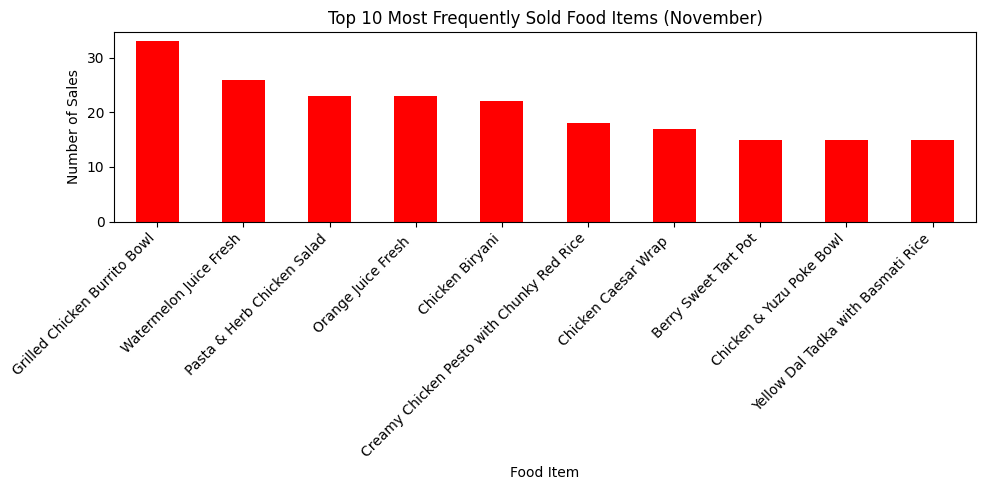

In [21]:
# Food Item Frequency Bar Chart
import matplotlib.pyplot as plt

# Count frequency of each food item from the November file
food_counts = df['Product Name'].value_counts().head(10)

plt.figure(figsize=(10,5))
food_counts.plot(kind='bar', color='red')

plt.title("Top 10 Most Frequently Sold Food Items (November)")
plt.xlabel("Food Item")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


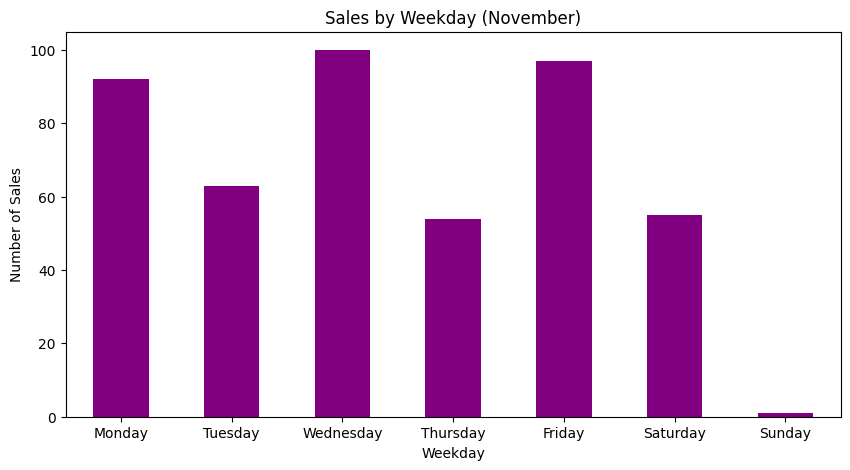

In [22]:
# Sales By Weekday
import matplotlib.pyplot as plt
import pandas as pd

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format="%d-%m-%y %H:%M", errors='coerce')

# Count weekday frequency
weekday_counts = df['Transaction Date'].dt.weekday.value_counts().sort_index()

# Weekday labels
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar', color='purple')

plt.title("Sales by Weekday (November)")
plt.xlabel("Weekday")
plt.ylabel("Number of Sales")
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=0)
plt.show()
